## 🔄 원본 트랜스포머와 GPT의 핵심 차이점

원본 트랜스포머(Transformer) 모델이 발전하여 GPT(Generative Pre-trained Transformer)가 되면서 변경된 핵심 구조적 차이점입니다.

### 1. 포지셔널 인코딩(Encoding) $\rightarrow$ 포지셔널 임베딩(Embedding)
* **트랜스포머:** 수학적인 공식(Sin, Cos 함수)을 사용하여 고정된 위치 정보(Positional Encoding)를 주입합니다.
* **GPT:** 모델이 학습 과정에서 스스로 단어의 위치와 순서를 깨우치도록 하는 **학습 가능한 임베딩(Learned Positional Embedding)** 층을 사용합니다. 위치 정보마저도 데이터로부터 학습하게 됩니다.

### 2. 인코더(Encoder) 구조의 삭제
* **트랜스포머:** 번역을 위해 입력 문장을 이해하는 '인코더'와 목표 언어로 번역을 수행하는 '디코더' 양방향 구조를 가집니다.
* **GPT:** 인코더를 완전히 제거하고 오직 **디코더(Decoder) 블록만으로 구성**된 단방향(Autoregressive) 모델입니다. 입력을 하나로 묶어(ex: `질문문장 + 답변문장`) 처음부터 끝까지 순차적으로 다음 단어를 예측하는 방식만을 취합니다.

### 3. 크로스 어텐션(Cross-Attention) 레이어 제거
* **트랜스포머 디코더:** 자신이 만들어낸 결과물을 보는 '셀프 어텐션'과, 인코더가 넘겨준 입력 문장 정보를 참조하는 **'인코더-디코더 크로스 어텐션'** 두 가지 구조를 가집니다.
* **GPT 디코더:** 인코더 전체가 사라졌기 때문에 인코더를 참조하는 **크로스 어텐션 층도 완전히 삭제**되었습니다. 오로지 이전 토큰들만 참조하는 **마스크드 셀프 어텐션(Masked Self-Attention) 하나만 존재**합니다.

### 4. 파인튜닝(Fine-Tuning)을 위한 새로운 리니어(Linear) 층 추가
* **트랜스포머:** 오직 기계 번역이라는 단일 목적을 위해 설계되었으며, 맨 마지막에 단어 사전 크기에 맞춘 하나의 출력 리니어 층만 존재합니다.
* **GPT의 혁신:** 엄청난 양의 텍스트로 '다음 단어 맞추기(Pre-training)' 학습을 마친 강력한 언어 모델 꼭대기에, 챗봇, 감성 분석, 객관식 풀이 등 **특정 작업(Downstream Task)의 목적에 맞는 새로운 리니어 층(Task-specific Linear Head)을 덮어씌워 파인튜닝(Fine-tuning)** 할 수 있는 유연한 범용 구조를 제안했습니다. 이를 통해 하나의 모델로 다양한 문제를 풀 수 있게 되었습니다.

### 5. 투입구가 2개 $\rightarrow$ 투입구가 1개 (단일 시퀀스 구조)
* **트랜스포머 (Two Sequences):** 입력을 넣는 곳이 완전히 두 갈래로 나뉘어 있습니다. 
  * 인코더 투입구: "안녕?" (번역할 원문)
  * 디코더 투입구: "`<start>` Hello" (지금까지 번역된 결과)
* **GPT (Single Sequence):** 인코더가 날아갔기 때문에 투입구가 1개로 통일되었습니다. 질문과 답변을 따로 구분하는 별도의 모듈 없이, 아예 **`[질문] 안녕? <구분자> [답변] Hello` 처럼 양쪽 데이터를 억지로 하나로 길게 이어 붙여서(Concatenation)** 단일 문장으로 모델에 통째로 우겨넣습니다.

### 6. 입력 문장 전체에 대한 완전한 인과적 마스킹 (Causal Masking)
* **트랜스포머:** 인코더는 문장 전체를 한 번에 다 봅니다(양방향 참조). 질문 문장 내에서는 뒤에 나올 단어도 미리 볼 수 있습니다. 디코더에서만 미래를 못 보게 막습니다(Look-ahead Mask).
* **GPT:** 처음부터 끝까지 하나의 긴 문장으로 이어붙여 넣었기 때문에, 모델의 **첫 번째 층부터 마지막 층까지 단 한 번도 자기보다 뒤에 있는(미래의) 단어를 볼 수 없도록 일관되게 차단**합니다. 즉, '질문 내용'을 읽을 때조차도 순방향(왼쪽 $\rightarrow$ 오른쪽)으로만 읽어나가는 완전한 단방향(Unidirectional) 형태 구조로 통일되었습니다.

### 7. 활성화 함수(Activation Function)의 변화: ReLU $\rightarrow$ GELU
* **트랜스포머:** 기본적으로 ReLU($\text{Rectified Linear Unit}$)라는 함수를 사용합니다. 0보다 작으면 무조건 0을 출력하는 방식이죠.
* **GPT:** GELU($\text{Gaussian Error Linear Unit}$)라는 함수를 사용합니다. 0 근처에서 조금 더 부드럽게 곡선을 그리며 값을 처리하는데, 연구 결과 언어 모델의 복잡한 문맥을 파악하는 데 ReLU보다 더 효과적임이 입증되었습니다.

### 8. 미세 조정 시 '보조 목적 함수($L_1$)'의 결합
* **트랜스포머:** 미세 조정을 염두에 둔 구조가 아니었기에 단일 목적(번역)의 손실값만 계산합니다.
* **GPT:** 앞서 본 수식 $L_3 = L_2 + \lambda * L_1$처럼, 미세 조정 중에도 사전 학습 때 썼던 '언어 모델링 로스($L_1$)'를 버리지 않고 함께 계산합니다. 이는 구조적으로 지도 학습(시험)과 비지도 학습(독서)을 동시에 수행하도록 설계된 GPT만의 독특한 훈련 방식입니다.

### 9. 디코더 다중 적층 구조 (12 Layers)
* **트랜스포머:** 인코더 6층, 디코더 6층의 깊이를 기본으로 합니다.
* **GPT:** 인코더를 버린 대신, 디코더 블록을 기본적으로 **12층(GPT-1 Base 기준)**으로 훨씬 더 깊게 적층하여 모델이 스스로 언어의 복잡한 계층적 특징을 더 깊이 학습할 수 있는 거대한 구조를 택했습니다. 

### 10. 가중치 공유 (Weight Tying / Weight Sharing)
* **트랜스포머:** 입력 단어를 벡터로 바꾸는 '입력 임베딩 층'과 출력 확률을 계산하는 '출력 리니어 층'의 가중치를 독립적으로 둘지 공유할지 선택적이었습니다.
* **GPT:** 단어를 입력받을 때나 출력으로 맞출 때 모두 동일한 '단어 사전' 차원을 통과하므로, **입력 임베딩 행렬과 마지막 출력 리니어 행렬의 가중치를 완전히 똑같이 공유**합니다. 파라미터(메모리) 낭비를 대폭 줄이면서 단어의 의미적 연결을 더 단단하게 만듭니다.


### 11. 미세 조정 시 작업별(Task-Specific) 입력 구조의 템플릿화
* **트랜스포머:** 번역 외의 작업을 하려면 모델 자체를 각 태스크에 맞게 구조적으로 뜯어고쳐야 했습니다.문장 유사도(`[Start] 텍스트1 [Delim] 텍스트2 [Extract]`) 처럼 특정 작업에 맞추어 **입력 형태를 특수 토큰으로 묶는 방식(Input Transformations)**을 사용
* **GPT:** 텍스트 분류(`[Start] 텍스트 [Extract]`), 합니다. 모델 본체는 전혀 건드리지 않고 입력값 배열만 바꾸어 활용하는 일관성을 확립했습니다.


In [1]:
import os
import math
import re
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import gensim
from gensim.models import KeyedVectors
from konlpy.tag import Mecab
import sentencepiece as spm
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# 버전 확인 (정리된 이름 기준)
print(f"Numpy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"NLTK: {nltk.__version__}")
print(f"Gensim: {gensim.__version__}")


Numpy: 2.4.2
Pandas: 3.0.0
PyTorch: 2.10.0
NLTK: 3.9.2
Gensim: 4.4.0


In [2]:
CFG = {
    "PRE_MAX_LEN": 50,
    "GPT_MAX_LEN": (50 * 2),
    "DEVICE": (lambda: torch.device("cuda") if torch.cuda.is_available() 
        else torch.device("mps") if torch.backends.mps.is_available() 
        else torch.device("cpu")
    )(),
    "VOCAB_SIZE": 9000,
    "AUG_DATA": "data/ko.kv",
    "CHATBOT_DATA": "data/ChatbotData.csv",
    "TRAIN_SIZE": 0.8,
    "VAL_SIZE": 0.15,
    "TEST_SIZE": 0.05,

    "DROPOUT": 0.4,
    "D_MODEL": 512, #피쳐 하나의 단어를 표현하는특징..
    "D_FF": 1024,
    'N_LAYER': 12,
    "POS_LEN": 200,
    "N_HEAD": 8,

    "BATCH_SIZE": 128,
    "EPOCHS": 6,
    "WARMUP_STEPS": 600,
    "LABEL_SMOOTHING": 0.1,
    "WEIGHT_DECAY": 1e-4,

    "GRID_SEARCH": False
}

if(CFG["DEVICE"].type == "mps"):
    MOCAB_PATH = "/opt/homebrew/lib/mecab/dic/mecab-ko-dic"
    os.environ["MECABRC"] = MOCAB_PATH
    mecab = Mecab(MOCAB_PATH)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
else:
    mecab = Mecab()

In [3]:
df = pd.read_csv(CFG["CHATBOT_DATA"])
print(df.head())

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


In [4]:
questions = df['Q'].tolist()
answers   = df['A'].tolist()

print(questions[0])
print(answers[0])

12시 땡!
하루가 또 가네요.


In [5]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip() # 소문자 변환 및 양끝 공백 제거
    
    # 특수문자 양 옆에 공백을 넣어서 단어와 분리 (학습 효율 극대화!)
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence) 
    
    # 중복된 공백 하나로 축소
    sentence = re.sub(r'[" "]+', " ", sentence)
    
    # 한글, 영어, 숫자, 특수문자(?.!,) 외에는 모두 공백으로 대체
    sentence = re.sub(r"[^a-zA-Z0-9ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence)
    
    sentence = sentence.strip()
    return sentence


after_prepro_questions = list(map(preprocess_sentence, questions))

print(questions[:10])
print(after_prepro_questions[:10])

['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네', 'SD카드 망가졌어', 'SD카드 안돼', 'SNS 맞팔 왜 안하지ㅠㅠ', 'SNS 시간낭비인 거 아는데 매일 하는 중', 'SNS 시간낭비인데 자꾸 보게됨']
['12시 땡 !', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'ppl 심하네', 'sd카드 망가졌어', 'sd카드 안돼', 'sns 맞팔 왜 안하지ㅠㅠ', 'sns 시간낭비인 거 아는데 매일 하는 중', 'sns 시간낭비인데 자꾸 보게됨']


In [6]:

def build_corpus(src_data, tgt_data, tokenize_func, max_len=50):
    que_corpus = []
    ans_corpus = []
    
    # 세트 하나에 (질문, 답변) 튜플을 통째로 넣어서 쌍이 겹치는 것만 제거합니다.
    seen_pairs = set()
    
    for src, tgt in zip(src_data, tgt_data):
        pre_src = preprocess_sentence(src)
        pre_tgt = preprocess_sentence(tgt)
        
        # 1. 문장 쌍이 완전히 중복되는 경우만 필터링
        if (pre_src, pre_tgt) in seen_pairs:
            continue
            
        src_tokens = tokenize_func(pre_src)
        tgt_tokens = tokenize_func(pre_tgt)
        
        # 2. 길이 제한 확인
        if len(src_tokens) <= max_len and len(tgt_tokens) <= max_len:
            seen_pairs.add((pre_src, pre_tgt)) # 튜플로 저장
            que_corpus.append(src_tokens)
            ans_corpus.append(tgt_tokens)
                
    return que_corpus, ans_corpus



# 1. 작동 방식: "의미의 최소 단위로 쪼개기"
# 영어는 띄어쓰기만 해도 단어가 구분되지만(I like apple), 한국어는 그렇지 않죠. 그래서 mecab.morphs는 문장에서 **더 이상 쪼갤 수 없는 가장 작은 의미 단위(형태소)**를 찾아냅니다.

# 예시 문장: "학교에 갔다"
# 컴퓨터 내부 동작:
# 학교 (명사: 장소의 의미)
# 에 (조사: 방향을 나타냄)
# 갔 (동사 어근: 이동의 의미)
# 다 (어미: 문장의 끝맺음)
# 결과: ['학교', '에', '갔', '다']
# 2. 왜 그냥 띄어쓰기로 안 하나요?
# 만약 띄어쓰기("학교에", "갔다")로 쪼개면 어떤 문제가 생길까요?

# AI는 "학교에", "학교는", "학교가"를 완전히 다른 세 개의 단어로 암기해야 합니다.
# 하지만 mecab.morphs로 쪼개면 AI는 "학교"라는 핵심 단어 하나만 배우고, 뒤에 붙는 "에/는/가"만 상황에 맞춰 갈아 끼우면 된다는 것을 금방 깨닫습니다. 지능이 훨씬 효율적으로 발달하는 거죠.

# 전체 데이터(questions, answers)에 대해 먼저 수행
que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs, max_len=CFG["PRE_MAX_LEN"])
print(f"코퍼스 크기: {len(questions)}, {len(answers)}")   
print(f"최종 정제된 코퍼스 크기: {len(que_corpus)}, {len(ans_corpus)}")  


print(que_corpus[:10])
print(ans_corpus[:10])

코퍼스 크기: 11823, 11823
최종 정제된 코퍼스 크기: 11749, 11749
[['12', '시', '땡', '!'], ['1', '지망', '학교', '떨어졌', '어'], ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다'], ['3', '박', '4', '일', '정도', '놀', '러', '가', '고', '싶', '다'], ['ppl', '심하', '네'], ['sd', '카드', '망가졌', '어'], ['sd', '카드', '안', '돼'], ['sns', '맞', '팔', '왜', '안', '하', '지', 'ㅠㅠ'], ['sns', '시간', '낭비', '인', '거', '아', '는데', '매일', '하', '는', '중'], ['sns', '시간', '낭비', '인데', '자꾸', '보', '게', '됨']]
[['하루', '가', '또', '가', '네요', '.'], ['위로', '해', '드립니다', '.'], ['여행', '은', '언제나', '좋', '죠', '.'], ['여행', '은', '언제나', '좋', '죠', '.'], ['눈살', '이', '찌푸려', '지', '죠', '.'], ['다시', '새로', '사', '는', '게', '마음', '편해요', '.'], ['다시', '새로', '사', '는', '게', '마음', '편해요', '.'], ['잘', '모르', '고', '있', '을', '수', '도', '있', '어요', '.'], ['시간', '을', '정하', '고', '해', '보', '세요', '.'], ['시간', '을', '정하', '고', '해', '보', '세요', '.']]


In [7]:
# CFG의 비율을 계산에 활용
# 1단계: Train vs (Val + Test)
rem_size = CFG["VAL_SIZE"] + CFG["TEST_SIZE"]
que_train, que_rem, ans_train, ans_rem = train_test_split(
    que_corpus,
    ans_corpus,
    test_size=rem_size,
    shuffle=True,
    random_state=42,
)

# 2단계: 남은 데이터를 다시 Val과 Test로 분리
# (전체 대비 비율을 rem_size 내의 비율로 환산)
val_ratio = CFG["VAL_SIZE"] / rem_size 
que_val, que_test, ans_val, ans_test = train_test_split(
    que_rem,
    ans_rem,
    test_size=(1 - val_ratio), # 남는 부분이 Test_size가 됨
    shuffle=True,
    random_state=42,
)

print(f"[Configuration Split Result]")
print(f"- Train      : {len(que_train)} ({CFG["TRAIN_SIZE"]*100}%)")
print(f"- Validation : {len(que_val)} ({CFG["VAL_SIZE"]*100}%)")
print(f"- Test       : {len(que_test)} ({CFG["TEST_SIZE"]*100}%)")

[Configuration Split Result]
- Train      : 9399 (80.0%)
- Validation : 1762 (15.0%)
- Test       : 588 (5.0%)


In [8]:
word2vec = KeyedVectors.load(CFG["AUG_DATA"])
# 테스트
print("테스트 유사어:", word2vec.most_similar("사랑", topn=3))

테스트 유사어: [('슬픔', 0.7216663360595703), ('행복', 0.6759077906608582), ('절망', 0.6468985080718994)]


In [9]:
def lexical_sub(sentence, word2vec):
    """
    이미 토큰화된 리스트(sentence)를 입력받아
    Word2Vec 사전에 존재하는 단어만 후보로 삼아 유사어로 교체합니다.
    """
    res = []
    toks = sentence

    try:
        # 📌 핵심 수정: Word2Vec 사전에 존재하는 단어(=교체 가능한 단어)만 추려냅니다.
        valid_tokens = [tok for tok in toks if tok in word2vec.key_to_index]
        
        # 바꿀 수 있는 단어가 아예 없으면 원본 그대로 반환
        if not valid_tokens:
            return toks
            
        # 의미 있는 단어 중에서 랜덤 선택
        _from = random.choice(valid_tokens)
        
        # 유사어 추출 (너무 엉뚱한 단어가 안 나오게 TOP 5로 줄임)
        candidates = word2vec.most_similar(_from, topn=10)
        _to = random.choice(candidates)[0]
        
        # 선택된 단어 치환
        res = [tok if tok != _from else _to for tok in toks]
    except Exception as e:
        # 예측 불가능한 에러 발생 시 원본 반환
        res = toks

    return res

print("lexical_sub 함수 정의 완료 (수정본: 사전 기반 안전 추출)")


lexical_sub 함수 정의 완료 (수정본: 사전 기반 안전 추출)


In [10]:
# 1단계 (Q비틀기):
# 질문: "밥 먹었어?" -> "식사 했어?" (바뀜)
# 답변: "네, 먹었어요" (그대로)
# 효과: 모델이 **"비슷한 질문에는 똑같은 대답을 해야 한다"**는 것을 배웁니다. (질문의 다양성 확보)
# 2단계 (A비틀기):
# 질문: "밥 먹었어?" (그대로)
# 답변: "네, 식사했어요" (바뀜)
# 효과: 모델이 **"한 질문에도 여러 가지 유연한 대답이 가능하다"**는 것을 배웁니다. (표현의 다양성 확보)
# 3단계 (Q, A 동시 비틀기):
# 질문: "식사 했어?" (바뀜)
# 답변: "네, 식사했어요" (바뀜)
# 효과: 가장 강력한 과적합 방지책입니다. 모델이 특정 문장 쌍 자체를 암기해버리는 암기(Memorization) 현상을 원천 봉쇄하고, 진짜 문장의 의미를 파악하게 만듭니다.



added_que_corpus = []
added_ans_corpus = []
original_len = len(que_train)

print("1단계 증강 중: Augmented Q + Original A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(lexical_sub(que_train[i], word2vec))
    added_ans_corpus.append(ans_train[i])

print("2단계 증강 중: Original Q + Augmented A...")
for i in tqdm(range(original_len)):
    added_que_corpus.append(que_train[i])
    added_ans_corpus.append(lexical_sub(ans_train[i], word2vec))

# # (추가) 3단계: 질문과 답변을 동시에 비틀기 (가장 강력한 과적합 방지!)
# print("3단계 증강 중: Augmented Q + Augmented A...")
# for i in tqdm(range(original_len)):
#     added_que_corpus.append(lexical_sub(que_train[i], word2vec))
#     added_ans_corpus.append(lexical_sub(ans_train[i], word2vec))    

que_train += added_que_corpus
ans_train += added_ans_corpus

print(f"✅ 증강 완료! 최종 Train 코퍼스 크기: {len(que_train)}")

1단계 증강 중: Augmented Q + Original A...


  0%|          | 0/9399 [00:00<?, ?it/s]

100%|██████████| 9399/9399 [00:03<00:00, 2573.40it/s]


2단계 증강 중: Original Q + Augmented A...


100%|██████████| 9399/9399 [00:02<00:00, 3352.39it/s]

✅ 증강 완료! 최종 Train 코퍼스 크기: 28197


In [11]:
# 1. 훈련 데이터에 있는 모든 형태소를 하나의 리스트로 합칩니다.
# (que_train과 ans_train이 이미 Mecab으로 토큰화된 리스트라고 가정할 때)
all_morphs = []
for sentence in que_train + ans_train:
    all_morphs.extend(sentence)
# 2. set()을 사용하여 중복을 제거한 뒤 개수를 셉니다.
total_morph_types = len(set(all_morphs))
print(f"🔍 우리 데이터에 들어있는 전체 형태소 종류: {total_morph_types}개")
print(f"📏 현재 설정된 사전 크기(VOCAB_SIZE): {CFG['VOCAB_SIZE']}개")
# 차이 계산
if total_morph_types > CFG['VOCAB_SIZE']:
    print(f"⚠️ 현재 {total_morph_types - CFG['VOCAB_SIZE']}개의 형태소가 사전에 등록되지 못하고 생략되거나 더 쪼개지고 있습니다.")
else:
    print(f"✅ 현재 사전 크기가 여유로워서 모든 형태소를 다 담을 수 있습니다!")

🔍 우리 데이터에 들어있는 전체 형태소 종류: 8948개
📏 현재 설정된 사전 크기(VOCAB_SIZE): 9000개
✅ 현재 사전 크기가 여유로워서 모든 형태소를 다 담을 수 있습니다!


In [12]:

# 1. kor_corpus.txt
#  (재료 / 소스 데이터)
# 정체: 토크나이저를 가르치기 위해 사용된 순수 텍스트 파일입니다.
# 역할: Mecab으로 쪼개진 원본 챗봇 문장들이 주렁주렁 들어있습니다.
# 특징: 학습이 끝나면 사실상 삭제해도 됩니다. 이 파일을 보고 토크나이저('기계')가 "아, 우리 주인님은 이런 말투를 쓰는구나!"라고 공부를 다 끝냈기 때문이죠.


# 2. kor_spm.model
#  (기계 / 학습된 엔진)
# 정체: 트레이닝 과정을 거쳐 만들어진 핵심 바이너리(Binary) 파일입니다.
# 역할: 문장을 숫자로 바꾸거나 숫자를 문장으로 바꿀 때 쓰는 진짜 엔진입니다.
# 특징: 텍스트 에디터로 열면 깨진 글자만 보입니다(이진 데이터). 나중에 챗봇 서비스를 할 때 이 파일 하나만 있으면 됩니다.

# 3. kor_spm.vocab
#  (사용설명서 / 어휘 목록)
# 정체: 토크나이저가 공부해서 정한 1만 개의 단어 조각(Token) 목록입니다.
# 역할: 어떤 조각에 몇 번 번호가 붙었는지 보여줍니다.
# 특징: 텍스트 에디터로 열면 사람이 직접 읽을 수 있습니다.
# <s>   0
# </s>   1
#  나   56
# ... 이런 식으로 되어 있어서, "내 챗봇이 어떤 단어를 제일 많이 배우나?" 궁금할 때 열어보시면 재밌습니다.





def generate_tokenizer(corpus, vocab_size, lang="kor", pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    file = f"./{lang}_corpus.txt"
    model = f"{lang}_spm"
    with open(file, 'w', encoding='utf-8') as f:
        for row in corpus: f.write(" ".join(row) + '\n')
    

    # 명령어 인자 사이에 공백(' ')이 확실히 들어가도록 수정
    # spa_spm.model: 퓨터만 읽을 수 있는 이진(Binary) 형태의 핵심 사전(모델) 파일입니다
    # spa_spm.vocab:  사람이 직접 눈으로 열어서 볼 수 있는 단순한 '어휘 텍스트 목록' 파일입니다.
    # 기본 Unigram
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model} --vocab_size={vocab_size} '
        f'--model_type=bpe '  # <--- 이 부분을 추가하면 3500개까지 잘 만들어질 겁니다.
        f'--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model}.model')
    return tokenizer

    
# Tokenizer는 Train 데이터만 보고 학습합니다.
tokenizer = generate_tokenizer(que_train + ans_train, CFG["VOCAB_SIZE"], "kor")
tokenizer.set_encode_extra_options("bos:eos")

sentencepiece_trainer.cc(178) LOG(INFO

True

) Running command: --input=./kor_corpus.txt --model_prefix=kor_spm --vocab_size=9000 --model_type=bpe --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./kor_corpus.txt
  input_format: 
  model_prefix: kor_spm
  model_type: BPE
  vocab_size: 9000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2


In [13]:
test_text = "너는 바다에 갔다."
print(tokenizer.encode_as_ids(test_text))
print(tokenizer.encode_as_pieces(test_text))

[1, 78, 7906, 2324, 7922, 3565, 7902, 2]
['<s>', '▁너', '는', '▁바다', '에', '▁갔다', '.', '</s>']


In [14]:

# 1 단계: Mecab (Morpheme) -> "쪼개기 기술자"
# 하는 일: 문장을 언어학적으로 의미 있는 조각들(형태소)로 나눕니다.
# 예시: "나도 밥 먹었어" -> ['나', '도', '밥', '먹', '었', '어']
# 특징: 사람이 읽기에 아주 완벽한 조각들이지만, 아직 "글자" 상태입니다. 컴퓨터는 아직 읽지 못하죠.
# 2단계: SentencePiece (BPE) -> "번호표 공장"
# 하는 일: Mecab이 쪼개준 글자 조각들을 모아서 통계적으로 가장 효율적인 단어장(1만 개)을 만들고, 각 조각에 **고유 번호(ID)**를 붙입니다. indexing
# 예시:
# '나' -> 56번
# '도' -> 12번
# '밥' -> 103번
# 특징: 이 과정이 끝나면 이제 "나도 밥 먹었어"가 [56, 12, 103...] 같은 숫자 배열로 바뀝니다. 비로소 AI(Transformer)가 계산할 수 있는 데이터가 되는 것입니다.


# tokenizer가  이제 텍스트 데이터셋을 진짜 숫자 데이터셋(indexing) 으로변환 
def make_corpus(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        sentence_str = " ".join(sentence)  
        tokens = tokenizer.encode_as_ids(sentence_str)
        corpus.append(tokens)
    return corpus



enc_train = make_corpus(que_train, tokenizer)
dec_train = make_corpus(ans_train, tokenizer)

enc_val = make_corpus(que_val, tokenizer)
dec_val = make_corpus(ans_val, tokenizer)

enc_test = make_corpus(que_test, tokenizer)
dec_test = make_corpus(ans_test, tokenizer)

100%|██████████| 588/588 [00:00<00:00, 203402.12it/s]


In [15]:
# for test
i = 0  # 보고 싶은 인덱스
# que_corpus -> que_train으로 변경
print("SRC original:", que_train[i])
print("SRC ids     :", enc_train[i])
# 이제 올바른 1차원 시퀀스이므로 정상 동작합니다.
src_pieces = [tokenizer.id_to_piece(tid) for tid in enc_train[i]]
print("SRC pieces  :", src_pieces)
print("SRC decoded :", tokenizer.decode_ids(enc_train[i]))
print("\n==== Decoder sample ====")

# ans_corpus -> ans_train으로 변경
print("TGT original:", ans_train[i])
print("TGT ids     :", dec_train[i])
# 올바른 1차원 시퀀스
tgt_pieces = [tokenizer.id_to_piece(tid) for tid in dec_train[i]]
print("TGT pieces  :", tgt_pieces)
print("TGT decoded :", tokenizer.decode_ids(dec_train[i]))

SRC original: ['썸', '타', '다', '깨졌', '는데', '다시', '연락', '해도', '되', '나', '.']
SRC ids     : [1, 97, 172, 22, 2303, 65, 203, 93, 170, 81, 23, 4, 2]
SRC pieces  : ['<s>', '▁썸', '▁타', '▁다', '▁깨졌', '▁는데', '▁다시', '▁연락', '▁해도', '▁되', '▁나', '▁.', '</s>']
SRC decoded : 썸 타 다 깨졌 는데 다시 연락 해도 되 나 .

==== Decoder sample ====
TGT original: ['감정', '에', '확신', '이', '있', '다면', '연락', '해', '보', '세요', '.']
TGT ids     : [1, 345, 21, 777, 5, 25, 272, 93, 10, 18, 17, 4, 2]
TGT pieces  : ['<s>', '▁감정', '▁에', '▁확신', '▁이', '▁있', '▁다면', '▁연락', '▁해', '▁보', '▁세요', '▁.', '</s>']
TGT decoded : 감정 에 확신 이 있 다면 연락 해 보 세요 .


In [16]:
def pad_sequences_custom(sequences, max_len=50, pad_value=0, bos_id=1, eos_id=2):
    padded_sequences = []

    for seq in sequences:
        # 텐서라면 리스트로 변환 (중복 실행 방지)
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
            
        # ⭐️ 핵심 방어 로직: 뒤쪽의 패딩(0) 찌꺼기들부터 말끔히 걷어냄
        while len(seq) > 0 and seq[-1] == pad_value:
            seq = seq[:-1]
            
        # 이미 bos/eos가 포함되어 있다면 제거 (명시적으로 처음부터 통제하기 위함)
        if len(seq) > 0 and seq[0] == bos_id:
             seq = seq[1:]
        if len(seq) > 0 and seq[-1] == eos_id:
             seq = seq[:-1]

        # max_len을 맞추기 위해 실제 단어가 들어갈 수 있는 공간은 (max_len - 2)
        max_word_len = max_len - 2 
        
        # 초과 길이는 자르기
        if len(seq) > max_word_len:
            seq = seq[:max_word_len]
            
        # [BOS] + 유효시퀀스 + [EOS] 조립
        seq = [bos_id] + seq + [eos_id]

        # 남은 길이는 pad_value로 채우기
        if len(seq) < max_len:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    return torch.tensor(padded_sequences, dtype=torch.long)


### GPT Input Transformations 매핑 분석

- [Delim] (질문과 답변의 구분점) [ 2, 1 ]
- [Start] (문장의 시작점) 1
- [Extract](문장의 끝) 2
 
```python
tensor([   1,   99,  173,   21, 2404,   64,  211,   96,  171,   81,   23,    4,
           2,    1,  360,   22,  766,    5,   25,  252,   96,   10,   19,   17,
           4,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0, ...])
```

In [17]:
gpt_train = [enc + dec for enc, dec in zip(enc_train, dec_train)]
gpt_val = [enc + dec for enc, dec in zip(enc_val, dec_val)]
gpt_test = [enc + dec for enc, dec in zip(enc_test, dec_test)]


gpt_train_padded = pad_sequences_custom(gpt_train, max_len=CFG["GPT_MAX_LEN"])
gpt_val_padded = pad_sequences_custom(gpt_val, max_len=CFG["GPT_MAX_LEN"])
gpt_test_padded = pad_sequences_custom(gpt_test, max_len=CFG["GPT_MAX_LEN"])
# 데이터 타입 변환 및 텐서 변환
enc_train_tensor = torch.tensor(gpt_train_padded, dtype=torch.long)
enc_val_tensor = torch.tensor(gpt_val_padded, dtype=torch.long)
enc_test_tensor = torch.tensor(gpt_test_padded, dtype=torch.long)
print("=== Tensor Shapes ===")
print("GPT 통합 방식 (단일 입력):")
print("enc_train_tensor shape:", enc_train_tensor.shape)
print("enc_val_tensor shape:", enc_val_tensor.shape)
print("\n=== Padding Data Check (Index 0) ===")
print("GPT로 하나로 이어진 문장의 패딩 검사:", enc_train_tensor[0])

/var/folders/ng/j7c3wxhn0lnclyqt41g9tcq80000gn/T/ipykernel_55992/1022754197.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  enc_train_tensor = torch.tensor(gpt_train_padded, dtype=torch.long)


=== Tensor Shapes ===
GPT 통합 방식 (단일 입력):
enc_train_tensor shape: torch.Size([28197, 100])
enc_val_tensor shape: torch.Size([1762, 100])

=== Padding Data Check (Index 0) ===
GPT로 하나로 이어진 문장의 패딩 검사: tensor([   1,   97,  172,   22, 2303,   65,  203,   93,  170,   81,   23,    4,
           2,    1,  345,   21,  777,    5,   25,  272,   93,   10,   18,   17,
           4,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0])


/var/folders/ng/j7c3wxhn0lnclyqt41g9tcq80000gn/T/ipykernel_55992/1022754197.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  enc_val_tensor = torch.tensor(gpt_val_padded, dtype=torch.long)
/var/folders/ng/j7c3wxhn0lnclyqt41g9tcq80000gn/T/ipykernel_55992/1022754197.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  enc_test_tensor = torch.tensor(gpt_test_padded, dtype=torch.long)


In [18]:
train_dataset = TensorDataset(enc_train_tensor)
val_dataset = TensorDataset(enc_val_tensor)
test_dataset = TensorDataset(enc_test_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=CFG["BATCH_SIZE"], shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=CFG["BATCH_SIZE"], shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=CFG["BATCH_SIZE"], shuffle=False)

print(f"총 Train 배치 개수: {len(train_dataloader)}")
print(f"총 Validation 배치 개수: {len(val_dataloader)}")
print(f"총 Test 배치 개수: {len(test_dataloader)}")

총 Train 배치 개수: 221
총 Validation 배치 개수: 14
총 Test 배치 개수: 5


In [19]:
# 어텐션 레이어가 단어 간의 "관계"를 파악한다면, 이 친구는 그 파악된 정보를 바탕으로 **"의미를 가공하고 정제"**하는 필터 역할을 합니다.
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff) # xW1 + b1  입력이 512, out이 2048
        self.fc2 = nn.Linear(d_ff, d_model) #  W2 + b2  입력이 2048, out이 512
        self.relu = nn.ReLU() # max(0, ...)

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out


d_model = 512
d_ff = 2048
ffn = PoswiseFeedForwardNet(d_model, d_ff)
# 2. 가상의 입력 데이터 (어텐션을 거쳐 막 나온 상태라고 가정)
sample_input = torch.randn(1, 10, d_model)
print("입력 데이터 크기:", sample_input.shape)
# 3. FFN 레이어 통과
sample_output = ffn(sample_input)
# 4. 결과 체크
print("출력 데이터 크기:", sample_output.shape) # 입력과 똑같이 (1, 10, 512)여야 함!
# 5. 간단한 값 변화 확인 (원본과 얼마나 달라졌나?)
print("첫 번째 단어의 처음 3개 값 변화:")
print("  - 입력:", sample_input[0, 0, :3].detach().numpy())
print("  - 출력:", sample_output[0, 0, :3].detach().numpy())       

입력 데이터 크기: torch.Size([1, 10, 512])
출력 데이터 크기: torch.Size([1, 10, 512])
첫 번째 단어의 처음 3개 값 변화:
  - 입력: [-0.8981366  1.8066292  2.154506 ]
  - 출력: [-0.34739596 -0.09798468 -0.35600436]


In [20]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        # d_model: 512 피쳐수 , 헤드 8
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수 64
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어: 하나의 단어...
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일

        # K [batch_size, num_heads, seq_len, depth] [64, 8, 50, 64]
        # K.transpose(-1, -2) 마지막 두 차원인 **-1(64)**과 **-2(50)**의 자리를 맞바꿉니다. [64, 8, 64, 50]

        # Q와 K의 내적: (batch_size, num_heads, seq_len, seq_len) [64, 8, 50, 64]  [64, 8, 64, 50] -> [64, 8, 50, 50]
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        # (batch_size, num_heads, seq_len, seq_len) 
        # Q 행(Rows): "누가 관심을 주나?" 답변 크로스어텐션에서는 디코더
        # K 열(Columns): "누구에게 관심을 주나?" 를 의미합니다. 질문  인코더
        # 인코더 셀프-어텐션: Q도 인코더, K도 인코더 (지들끼리 노는 것)
        # 디코더 셀프-어텐션: Q도 디코더, K도 디코더 (지들끼리 노는 것)
        # 인코더-디코더 어텐션 (사용자님 그림): Q는 디코더, K는 인코더 (서로 연결하는 것)
        # dim=-1 (열 방향, 가로): 왼쪽에서 오른쪽으로(→) 숫자를 뭉칩니다.
        # 결과: **가로 한 줄(행)**의 합이 100%가 됨.
        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        # attentions is attention distribution
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)
        # out is attention value

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        # [batch_size, seq_len, d_model] -> [batch_size, seq_len, num_heads, depth]: [64, 50, 512] -> [64, 50, 8, 64]
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        # WQ_splits: 8개의 다른 질문(Q) 팀
        # WK_splits: 8개의 다른 꼬리표(K) 팀
        # WV_splits: 8개의 다른 알맹이(V) 팀
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights


In [21]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
       

        self.do = nn.Dropout(dropout)

    def forward(self, x, padding_mask):
        # Masked Multi-Head Attention (이전 단어들만 참조)
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual


        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn


In [22]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, padding_mask):
        out = x
        dec_attns = []

        for i in range(self.n_layers):
            out, dec_attn = self.dec_layers[i](out, padding_mask)
            dec_attns.append(dec_attn)
           
        return out, dec_attns


## GPT 아키텍쳐
- 2개의 아키텍처로 나누었습니다.

### Pre-training 아키텍처
 - 이 클래스는 논문의 "3.1 Unsupervised pre-training" 단계를 담당하는 구조입니다.
 - 역할: 대규모 텍스트 데이터로부터 언어의 구조를 배우는 '언어 모델(Language Model)' 그 자체입니다.
 - 핵심 구현: * Decoder-only: 인코더 없이 디코더만 쌓아 올린 구조입니다.
 - Masked Self-Attention: 미래의 단어를 보지 않고 다음 단어를 예측하도록 설계되었습니다.
 - Generative Objective: train_step 함수를 보면 입력(tgt_in)을 넣어 다음 단어(gold)를 맞추는 Next Token Prediction 방식으로 학습됩니다. 


 ### Fine Tunning 아키텍처 - 긍정/부정 판독기 (Classification)
 - GPTChatbot class가 파일 가장 하단에 정의 되어 있습니다.

In [23]:
class GPT(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 vocab_size, pos_len, dropout=0.2):
        super(GPT, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        self.emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(pos_len, d_model)
        self.do = nn.Dropout(dropout)

        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, vocab_size)
        
        self.fc.weight = self.emb.weight 

    def embedding(self, x):
        """
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        batch_size, seq_len = x.size()
        out = self.emb(x)  # [batch_size, seq_len, d_model]

        out = out * math.sqrt(self.d_model)
        
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        out = out + self.pos_emb(positions)
        out = self.do(out)
        return out

    def forward(self, x, mask):
        """
        x: [batch_size, seq_len] (질문과 답변이 결합된 연속된 토큰)
        mask: [batch_size, 1, seq_len, seq_len] (미래를 못보게 하는 Look-ahead 역할)
        """
        x_emb = self.embedding(x)

        dec_out, dec_attns = self.decoder(x_emb, mask)
        logits = self.fc(dec_out)

        return logits, dec_attns


In [24]:
# 주어진 하이퍼파라미터로 GPT 인스턴스 생성
gpt_model = GPT(
    n_layers=CFG["N_LAYER"],
    d_model=CFG["D_MODEL"],
    n_heads=CFG["N_HEAD"],                 # 어텐션 헤드 개수
    d_ff=CFG["D_FF"],
    vocab_size=CFG["VOCAB_SIZE"], # 💡 src/tgt 구분 없이 단일 단어장 하나만 전달!
    pos_len=CFG["POS_LEN"],               # 모델이 소화할 수 있는 문장의 최대 길이 (위치 번호판 개수)
    dropout=CFG["DROPOUT"]
)
# 모델을 GPU(또는 MPS, CPU) 메모리에 올리기
gpt_model = gpt_model.to(CFG["DEVICE"])

# 모델 구조 출력
print(gpt_model)

GPT(
  (emb): Embedding(9000, 512)
  (pos_emb): Embedding(200, 512)
  (do): Dropout(p=0.4, inplace=False)
  (decoder): Decoder(
    (dec_layers): ModuleList(
      (0-11): 12 x DecoderLayer(
        (dec_self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=512, out_features=512, bias=True)
          (W_k): Linear(in_features=512, out_features=512, bias=True)
          (W_v): Linear(in_features=512, out_features=512, bias=True)
          (linear): Linear(in_features=512, out_features=512, bias=True)
        )
        (ffn): PoswiseFeedForwardNet(
          (fc1): Linear(in_features=512, out_features=1024, bias=True)
          (fc2): Linear(in_features=1024, out_features=512, bias=True)
          (relu): ReLU()
        )
        (norm_1): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (norm_2): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
        (do): Dropout(p=0.4, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=512, out_features=9000,

In [25]:
def loss_function(real, pred, label_smoothing=0.0):
    """
    real: [batch_size, seq_len] 
    pred: [batch_size, seq_len, num_classes] 
    """
    real = real.to(CFG["DEVICE"])
    pred = pred.to(CFG["DEVICE"])

    # 예측 텐서 [B*seq_len, num_classes] 로 변환
    pred = pred.view(-1, pred.size(-1))
    # 정답 텐서 [B*seq_len] 로 변환
    real = real.contiguous().view(-1)

    # 📌 수정된 로직: label_smoothing=0.1 추가
    # ignore_index=0: 패딩 토큰(0)은 무시
    # label_smoothing=0.1: 모델의 과잉 확신을 방지하여 과적합 억제
    
    return F.cross_entropy(pred, real, ignore_index=0, label_smoothing=label_smoothing)

In [26]:
def calculate_accuracy(real, pred):
    # 가장 높은 확률을 가진 단어의 인덱스(번호) 추출
    predictions = torch.argmax(pred, dim=-1)
    
    # 0번(패딩) 자리는 빼고 진짜 단어들만 1.0으로 마킹
    mask = (real != 0).float()
    
    # 내가 찍은 답이랑 실제 정답이 똑같으면 1점 확보
    correct = (predictions == real).float()
    
    # 가짜 빈칸 찍어맞춘 점수 무효화시키고 최종 정확도 % 구하기
    accuracy = (correct * mask).sum() / mask.sum()
    
    return accuracy

In [27]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(x: torch.Tensor):
    seq_len = x.shape[1]
    
    padding_mask = generate_padding_mask(x)           
    lookahead_mask = generate_lookahead_mask(seq_len)  
    lookahead_mask = lookahead_mask.unsqueeze(0).unsqueeze(1)  
    padding_mask = padding_mask.to(CFG["DEVICE"])
    lookahead_mask = lookahead_mask.to(CFG["DEVICE"])
    mask = torch.max(padding_mask, lookahead_mask)
    return mask


sample_x = torch.tensor([
    [10, 20, 30, 0, 0],
    [40, 50, 60, 70, 0]
]).to(CFG["DEVICE"])
mask = generate_masks(sample_x)
print("입력 텐서 모양:", sample_x.shape)
print("생성된 마스크 모양:", mask.shape)
print("첫 번째 데이터(10, 20, 30, 0, 0)의 마스크 세부 내용:")
print(mask[0, 0, :, :])

입력 텐서 모양: torch.Size([2, 5])
생성된 마스크 모양: torch.Size([2, 1, 5, 5])
첫 번째 데이터(10, 20, 30, 0, 0)의 마스크 세부 내용:
tensor([[0., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1.],
        [0., 0., 0., 1., 1.],
        [0., 0., 0., 1., 1.],
        [0., 0., 0., 1., 1.]], device='mps:0')


In [28]:
def train_step(x, model, optimizer, label_smoothing=0.0):
    model.train()
    optimizer.zero_grad()

    tgt_in = x[:, :-1]
    gold = x[:, 1:]

    # GPT 전용 마스크 1개만 생성
    mask = generate_masks(tgt_in)

    # 장치 할당
    tgt_in = tgt_in.to(CFG["DEVICE"])
    gold = gold.to(CFG["DEVICE"])
    mask = mask.to(CFG["DEVICE"])

    # 모델 통과 (GPT는 predictions와 attention 2개만 반환합니다)
    predictions, _ = model(tgt_in, mask)
    
    # Loss 및 Accuracy 계산
    loss = loss_function(gold, predictions, label_smoothing=label_smoothing)
    acc = calculate_accuracy(gold, predictions)

    loss.backward()
    optimizer.step()

    return loss, acc


In [29]:
def val_step(x, model, label_smoothing=0.0):
    model.eval()
    with torch.no_grad():
        tgt_in = x[:, :-1]
        gold = x[:, 1:]
        mask = generate_masks(tgt_in)
        tgt_in = tgt_in.to(CFG["DEVICE"])
        gold = gold.to(CFG["DEVICE"])
        mask = mask.to(CFG["DEVICE"])
        predictions, _ = model(tgt_in, mask)
        loss = loss_function(gold, predictions, label_smoothing=label_smoothing)
        acc = calculate_accuracy(gold, predictions)

    return loss, acc


In [30]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = max(1.0, float(step))
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)


In [31]:
learning_rate = LearningRateScheduler(CFG["D_MODEL"], warmup_steps=CFG["WARMUP_STEPS"])

optimizer = torch.optim.AdamW(gpt_model.parameters(),
                             lr=1.0,
                             betas=(0.9, 0.98),
                             eps=1e-9,
                             weight_decay=CFG["WEIGHT_DECAY"]
                            )
                            
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=learning_rate)

In [32]:


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
best_epcho= CFG["EPOCHS"]

for epoch in range(CFG["EPOCHS"]):
    # --- [ TRAIN ] ---
    gpt_model.train()
    total_train_loss, total_train_acc = 0.0, 0.0
    train_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1} [Train]")

    for batch, (x,) in enumerate(train_dataloader):
        loss, acc = train_step(x, gpt_model, optimizer)
        
        # 옵티마이저가 한 발자국 나갔으니 스케줄러도 한 발자국 전진시킵니다.
        scheduler.step()
        
        total_train_loss += loss.item()
        total_train_acc += acc.item()
        
        train_bar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{acc.item():.4f}"})
        train_bar.update(1)
    train_bar.close()

    # --- [ VALIDATION ] ---
    gpt_model.eval()
    total_val_loss, total_val_acc = 0.0, 0.0
    val_bar = tqdm(total=len(val_dataloader), desc=f"Epoch {epoch+1} [Val]")

    for batch, (x,) in enumerate(val_dataloader):
        v_loss, v_acc = val_step(x, gpt_model)
        
        total_val_loss += v_loss.item()
        total_val_acc += v_acc.item()
        
        val_bar.set_postfix({"Loss": f"{v_loss.item():.4f}", "Acc": f"{v_acc.item():.4f}"})
        val_bar.update(1)
    val_bar.close()

    # --- [ 최종 결과 계산 및 기록 ] ---
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_acc / len(train_dataloader)
    avg_val_loss = total_val_loss / len(val_dataloader)
    avg_val_acc = total_val_acc / len(val_dataloader)
    
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    # Best Model 저장
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epcho = epoch+1
        torch.save(gpt_model.state_dict(), 'best_model.pth')
        print(f"\n🔥 Best model saved! (Val Loss: {best_val_loss:.4f})")
    
    print(f"\n✨ Epoch {epoch+1} Summary")
    print(f"   - Train Loss: {avg_train_loss:.4f}  |  Train Acc: {avg_train_acc:.4f}")
    print(f"   - Val Loss  : {avg_val_loss:.4f}  |  Val Acc  : {avg_val_acc:.4f}")
    print("-" * 60)


Epoch 1 [Val]: 100%|██████████| 14/14 [00:02<00:00,  4.75it/s, Loss=1804.6583, Acc=0.2564]



🔥 Best model saved! (Val Loss: 1843.8337)

✨ Epoch 1 Summary
   - Train Loss: 5964.4351  |  Train Acc: 0.1311
   - Val Loss  : 1843.8337  |  Val Acc  : 0.2530
------------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 14/14 [00:03<00:00,  4.64it/s, Loss=508.4138, Acc=0.1907]



🔥 Best model saved! (Val Loss: 521.8943)

✨ Epoch 2 Summary
   - Train Loss: 1214.3190  |  Train Acc: 0.2198
   - Val Loss  : 521.8943  |  Val Acc  : 0.1858
------------------------------------------------------------


Epoch 3 [Val]: 100%|██████████| 14/14 [00:02<00:00,  4.73it/s, Loss=41.3636, Acc=0.1129]


...


🔥 Best model saved! (Val Loss: 25.9662)

✨ Epoch 4 Summary
   - Train Loss: 46.4269  |  Train Acc: 0.1962
   - Val Loss  : 25.9662  |  Val Acc  : 0.1510
------------------------------------------------------------


Epoch 5 [Val]: 100%|██████████| 14/14 [00:02<00:00,  4.78it/s, Loss=17.1486, Acc=0.0866]



🔥 Best model saved! (Val Loss: 17.2883)

✨ Epoch 5 Summary
   - Train Loss: 33.1377  |  Train Acc: 0.1953
   - Val Loss  : 17.2883  |  Val Acc  : 0.0832
------------------------------------------------------------


Epoch 6 [Val]: 100%|██████████| 14/14 [00:02<00:00,  4.78it/s, Loss=16.9156, Acc=0.0860]



🔥 Best model saved! (Val Loss: 17.0129)

✨ Epoch 6 Summary
   - Train Loss: 25.1508  |  Train Acc: 0.1965
   - Val Loss  : 17.0129  |  Val Acc  : 0.0883
------------------------------------------------------------


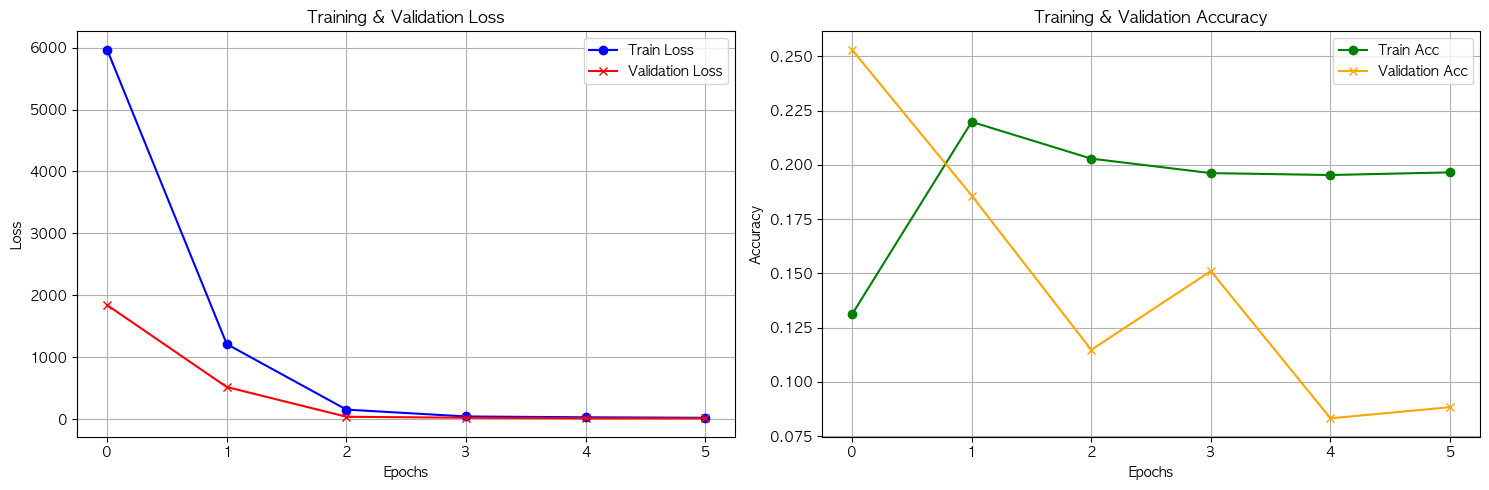

In [37]:
# 1. 시각화 영역 설정 (1행 2열)
plt.figure(figsize=(15, 5))
# --- 좌측: Loss 그래프 ---
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', color='red', marker='x')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# --- 우측: Accuracy 그래프 ---
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='green', marker='o')
plt.plot(history['val_acc'], label='Validation Acc', color='orange', marker='x')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
def calculate_bleu(reference, candidate):
    return sentence_bleu([reference], candidate, smoothing_function=SmoothingFunction().method1)

In [39]:


def evaluate(sentence, model, tokenizer, max_len=50):
    model.eval()
    
    # 1. 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(sentence)
    tokens = tokenizer.encode_as_ids(" ".join(mecab.morphs(sentence)))
    
    # 2. [GPT 핵심 프롬프트 세팅] (Input Transformations)
    # 던져줄 질문에 시작(1)과 끝(2)을 감싸고, 바로 이어서(1) 대답하라고 판을 깔아줍니다.
    input_ids = [1] + tokens + [2, 1]
    
    # 모델에 던질 1차선 텐서로 포장
    x = torch.tensor([input_ids], dtype=torch.long).to(CFG["DEVICE"])
    
    # 나중에 프롬프트 잘라내기 위해 질문 길이를 기억해 둡니다.
    prompt_len = len(input_ids)
    
    for i in range(max_len):
        with torch.no_grad():
            # [추가된 핵심!!!] 
            # 모델이 아직 예측하지 않은 미래를 컨닝(우상단)하지 못하게 실시간 마스크를 짜맞춥니다.
            seq_len = x.size(1)
            lookahead_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).to(CFG["DEVICE"])
            pad_mask = (x == 0).unsqueeze(1).unsqueeze(2).float().to(CFG["DEVICE"])
            gpt_mask = torch.max(pad_mask, lookahead_mask)
            
            # 마스크를 방패 삼아 GPT 내부로 문장을 돌진시킵니다!
            outputs = model(x, gpt_mask)
            
            # 파이토치 구조상 튜플로 반환될 수 있으므로 Logits(로짓) 값만 뜯어냅니다.
            if isinstance(outputs, tuple):
                predictions = outputs[0]
            else:
                predictions = outputs
                
        # 한참 긴 전체 문장에서 제일 마지막(가장 최신) 단어의 확률값 도출
        last_word_logits = predictions[:, -1, :]
        
        # 확률이 제일 높은 단어를 1등으로 선택
        predicted_id = torch.argmax(last_word_logits, dim=-1).unsqueeze(0)
        
        # 모델 스스로 문장의 끝점(Extract/EOS)인 토큰 2번을 뽑아내면, 즉시 입을 닫습니다!
        if predicted_id.item() == 2:
            break
            
        # 방금 뱉어낸 단어를 기존 문장 맨 뒤쪽에 이어붙임 (이 꼬리물기가 무한 반복됩니다)
        x = torch.cat([x, predicted_id], dim=-1)
        
    # 3. 답변 해석 (디코딩)
    # 합쳐진 전체 문장 속에서 [내가 던진 질문 부분]은 가위로 싹둑 잘라내고,
    # GPT가 자기 힘으로 이어붙인 순수 후반부(답변) 단어 번호들만 글자로 가져옵니다.
    answer_tokens = x.squeeze().tolist()[prompt_len:]
    result = tokenizer.decode_ids(answer_tokens)
    
    return result

In [41]:
# --- [ 최종 제출 양식 출력 셀 ] ---
# 1. 테스트 예문 정의
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]
print("# 예문")
for i, s in enumerate(test_sentences):
    print(f"{i+1}. {s}")
print("\n---\n")
print("# 제출\n")
# 2. Translations (실제 추론 결과)

print("Translations")
for i, sentence in enumerate(test_sentences):
    # GPT 모델로 교체!
    answer = evaluate(sentence, gpt_model, tokenizer)
    print(f"> {i+1}. {answer} <end>")
# 3. Hyperparameters (GPT는 인코더가 없기 때문에 CFG 설정값으로 심플하게 출력합니다!)
print("\nHyperparameters")
print(f"> n_layers: {CFG['N_LAYER']}")
print(f"> d_model:  {CFG['D_MODEL']}")
print(f"> N_HEAD:  {CFG['N_HEAD']}")
print(f"> d_ff:     {CFG['D_FF']}")
print(f"> dropout:  {CFG['DROPOUT']}")
# 4. Training Parameters
print("\nTraining Parameters")
print(f"> Warmup Steps: {CFG['WARMUP_STEPS']}") # 객체 접근 대신 안전한 CFG 권장
print(f"> Batch Size: {CFG['BATCH_SIZE']}")
print(f"> Epochs: {CFG['EPOCHS']}")

# 예문
1. 지루하다, 놀러가고 싶어.
2. 오늘 일찍 일어났더니 피곤하다.
3. 간만에 여자친구랑 데이트 하기로 했어.
4. 집에 있는다는 소리야.

---

# 제출

Translations
> 1. 안 사람 . <end>
> 2. 답답증 . 하 챙긴다는 가 . 안 . 안 . 안 가 . 가 . 해 가 가 . . . 가 가 가 이 이 . . . . . . . . . . 안 해 가 가 . 가 가 가 가 이 . . 가 . <end>
> 3. 졸린데 했 . 이상 가 를 를 . . 안 . . 안 사람 <end>
> 4. 졸린데 어요 . 이 를 . 했 사람 어요 . 안 . 안 . . . 안 . . . . . . . . 가 안 . 안 요 가 . . . . . 가 이 먼저 해 가 가 이 해 가 가 이 짝 가 가 <end>

Hyperparameters
> n_layers: 12
> d_model:  512
> N_HEAD:  8
> d_ff:     1024
> dropout:  0.4

Training Parameters
> Warmup Steps: 600
> Batch Size: 128
> Epochs: 6


## Fine 튜닝 GPT 아키텍처 - 긍정/부정 판독기 (Classification)
* `__init__` 함수에서 `self.gpt_model = gpt_model` 을 통해, 앞서 며칠 밤낮(?)을 훈련시킨 소중한 사전학습 가중치를 그대로 업어옵니다. 구조를 새로 짜는 것이 아니라 기존 뇌 구조를 100% 재활용합니다.
* [Extract] 토큰 추출과 Task Head 연결 ($h_l^m$)
* 논문의 지시대로, 거대한 시퀀스 전체를 분류기에 넣는 것이 아니라 문장의 대미를 장식하는 가장 마지막 토큰인 `[Extract]` 토큰 위치(`extract_indices`)의 히든 스테이트(Hidden States)**만을 정밀하게 도려냅니다 (`h_m_l`).
* 도려낸 이 1차원 벡터를 우리가 새로 달아준 `task_head (nn.Linear)` 막판 판사봉에 넘겨 정답(분류) 확률을 뽑아냅니다.
**3. 보조 목적 함수 결합 수식 ($L_3 = L_2 + \lambda L_1$)**
* **$L_2$ (Task Loss)**: 당면한 문제(객관식 정답 맞추기)를 틀렸을 때 발생하는 에러입니다. (`loss_task`)
* **$L_1$ (LM Loss)**: 모델이 당면한 문제 풀기에만 너무 집착한 나머지, 원래 자기가 가지고 있던 "한국어 문장 생성 능력(Language Modeling)"을 까먹는 것(Catastrophic Forgetting)을 막기 위해 켜두는 방어용 보조 로스입니다. (`loss_lm`)
* 최종적으로 이 두 로스를 `lambda_aux` (약 0.5) 비율로 섞어 최종 오차(`total_loss`)를 계산하는 논문의 철학을 완벽하게 코드로 구현해 냈습니다

In [ ]:
import torch
import torch.nn as nn
class GPTChatbot(nn.Module):
    def __init__(self, gpt_model, num_classes=2, lambda_aux=0.5):
        super(GPTChatbot, self).__init__()
        # 1. 아까 훈련시킨 순수 GPT 구조체를 그대로 가져옵니다.
        self.gpt_model = gpt_model
        
        # 2. 논문의 파인튜닝 전용 구조 (판사 봉)
        self.task_head = nn.Linear(CFG["D_MODEL"], num_classes)
        
        # 3. 보조 목적 함수(언어 생명줄) 반영 비율
        self.lambda_aux = lambda_aux
        
    def forward(self, input_ids, extract_indices, labels=None):
        # 1. 훈련 때처럼 미래를 못 보게끔 룩어헤드 마스크 + 패딩 마스크를 동적으로 생성합니다.
        seq_len = input_ids.size(1)
        lookahead_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).to(CFG["DEVICE"])
        pad_mask = (input_ids == 0).unsqueeze(1).unsqueeze(2).float().to(CFG["DEVICE"])
        gpt_mask = torch.max(pad_mask, lookahead_mask)
        
        # A. [핵심 수정 부분] 사용자님의 GPT 클래스 내부 부품을 직접 호출하여 
        # (vocab_size로 바뀌기 직전의) 512차원 히든 스테이트를 뽑아냅니다!
        x_emb = self.gpt_model.embedding(input_ids)
        hidden_states, _ = self.gpt_model.decoder(x_emb, gpt_mask)
        
        # B. 배치 안의 각 문장마다 [Extract] 토큰이 있던 위치의 값(h_m_l)만 쏙 빼냅니다!
        batch_size = input_ids.size(0)
        batch_indices = torch.arange(batch_size)
        h_m_l = hidden_states[batch_indices, extract_indices]
        
        # C. 쏙 빼온 그 값을 판사 봉에 던져서 정답 확률(Task Logits)을 구합니다!
        task_logits = self.task_head(h_m_l)
        
        # D. 만약 정답지(labels)가 들어왔다면 로스(L1+L2)를 합산하여 계산합니다.
        if labels is not None:
            # L2: 메인 태스크 정답 오차 (긍정/부정 맞추기)
            loss_task = nn.CrossEntropyLoss()(task_logits, labels)
            
            # L1: 기초 체력 오차 (GPT 원래 기능인 fc 레이어를 통과시켜 다음 단어 예측)
            lm_logits = self.gpt_model.fc(hidden_states) 
            
            # 다음 단어를 맞추기 위해 shift 세팅
            shift_logits = lm_logits[..., :-1, :].contiguous()
            shift_labels = input_ids[..., 1:].contiguous()
            loss_lm = nn.CrossEntropyLoss(ignore_index=0)(
                shift_logits.view(-1, shift_logits.size(-1)), 
                shift_labels.view(-1)
            )
            
            # 논문의 수식 (L3 = L2 + lambda * L1) 완벽 구현!
            total_loss = loss_task + (self.lambda_aux * loss_lm)
            return task_logits, total_loss
        
        return task_logits

In [49]:

dummy_texts = [
    # --- 긍정적 리뷰 (Label: 1) ---
    "영화 진짜 너무 감동적이었어!",
    "올해 최고의 수작입니다 강추!",
    "배우들 연기가 일품이네요. 무조건 꼭 보세요.",
    "시간 가는 줄 모르고 봤습니다. 전개 미쳤음.",
    "이런 명작을 이제야 보다니 내 인생 레전드.",
    "여운이 깊게 남는 훌륭한 작품입니다.",
    "액션 씬이 정말 화려하고 심장 쫄깃해요!",
    "부모님 모시고 다 같이 봐도 너무 따뜻한 영화.",
    "OST가 아직도 귓가에 맴돕니다. 음악까지 최고!",
    "기승전결 완벽한 영화, 10점 만점에 10점 줍니다.",
    "감독의 연출력이 정말 천재적이네요. 숨 막힘.",
    "웃음과 눈물을 동시에 주는 완성도 높은 갓명작.",
    
    # --- 부정적 리뷰 (Label: 0) ---
    "시간 아까워 내 돈 내놔...",
    "연기력은 좋았는데 스토리가 폭망이네",
    "내용이 산으로 가는 개연성 제로의 영화입니다.",
    "보다가 중간에 퍼질러 잠들었어요 지루해 죽음",
    "예고편이 전부인 전형적인 낚시성 영화의 끝판왕",
    "굳이 비싼 돈 주고 영화관 가서 볼 수준은 절대 아님.",
    "감독 열반하신 줄.. 결말이 너무 허무해서 어이가 없네.",
    "주연 배우 연기 구멍이 너무 커서 몰입이 싹 다 깨짐.",
    "돈 주고 보지 말고 그냥 당근마켓에 양도하세요.",
    "천만 원 더 준다고 해도 다시는 안 볼 쓰레기 영화.",
    "B급 감성인 줄 알았는데 그냥 D급 수준 하급 코미디.",
    "억지 감동 쥐어짜는 식상한 신파극 이제 지긋지긋함."
]
dummy_labels = [
    # 앞쪽 12개는 긍정(1), 뒤쪽 12개는 부정(0) 정답 라벨
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
]
def build_sentiment_dataset(texts, labels, tokenizer, max_len=60):
    input_ids_list = []
    extract_indices_list = []
    
    for text in texts:
        # A. 정규식 전처리와 형태소 분석(Mecab) 후 숫자 아이디로 번역
        processed_text = preprocess_sentence(text)
        tokens = tokenizer.encode_as_ids(" ".join(mecab.morphs(processed_text)))
        
        # B. [논문의 규칙] 단일 문장 분류 포맷 조립! (Start=1, Extract=2)
        current_input = [1] + tokens + [2]
        
        # C. [완전 핵심] 문장 맨 끝에 박힌 Extract(2번) 토큰의 "위치 인덱스"를 무조건 기억
        extract_idx = len(current_input) - 1
        
        # D. 모자란 칸 0으로 칠하기 (패딩)
        if len(current_input) < max_len:
            current_input += [0] * (max_len - len(current_input))
        else:
            # 칸이 부족하면 맨 끝에 억지로 Extract(2) 박고 자르기
            current_input = current_input[:max_len]
            current_input[-1] = 2
            extract_idx = max_len - 1
            
        input_ids_list.append(current_input)
        extract_indices_list.append(extract_idx)
        
    # E. 완성된 리스트들을 파이토치의 자랑거리인 텐서 블록으로 압축!
    t_inputs = torch.tensor(input_ids_list, dtype=torch.long)
    t_extracts = torch.tensor(extract_indices_list, dtype=torch.long)
    t_labels = torch.tensor(labels, dtype=torch.long)
    
    return TensorDataset(t_inputs, t_extracts, t_labels)


sentiment_dataset = build_sentiment_dataset(dummy_texts, dummy_labels, tokenizer)
sentiment_dataloader = DataLoader(sentiment_dataset, batch_size=2, shuffle=True)
# 3. 데이터 출력 확인 (훈련 포문에서 이렇게 3갈래로 받아가게 됩니다!)
for inputs, extracts, labels in sentiment_dataloader:
    print(f"입력문장 텐서: {inputs}")
    print(f"Extract 토큰 위치 번호들: {extracts}")
    print(f"긍정/부정 정답지: {labels}")
    break   


입력문장 텐서: tensor([[   1,    1,  630,  318,   86, 3962,  117,    5,   88,    8,  147,    2,
            2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0],
        [   1,    1, 3742,  320,   77,  200,  563,  170,  203,    6,   50,  207,
         1532,  630,    4,    2,    2,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0]])
Extract 토큰 위치 번호들: tensor([12, 16])
긍정/부정 정답지: tensor([1, 0])


In [50]:
from torch.optim import AdamW
from tqdm import tqdm

base_gpt = GPT(
    vocab_size=CFG["VOCAB_SIZE"], 
    d_model=CFG["D_MODEL"], 
    n_layers=CFG["N_LAYER"], 
    n_heads=CFG["N_HEAD"], 
    d_ff=CFG["D_FF"], 
    dropout=CFG["DROPOUT"],
    pos_len=CFG["POS_LEN"]
)

base_gpt.load_state_dict(torch.load('best_model.pth'))
print("🎉 사전학습된 가중치 로드 성공! (한국어 뇌 이식 완료)")

ft_model = GPTChatbot(base_gpt, num_classes=2, lambda_aux=0.5).to(CFG["DEVICE"])
optimizer_ft = AdamW(ft_model.parameters(), lr=2e-5)

FT_EPOCHS = 5
for epoch in range(FT_EPOCHS):
    ft_model.train()
    total_ft_loss, correct, total_items = 0.0, 0, 0
    
    # 아까 만든 데이터로더 (3가지를 순서대로 뱉어냅니다)
    ft_bar = tqdm(total=len(sentiment_dataloader), desc=f"Fine-Tuning Epoch {epoch+1}")
    for batch, (inputs, extracts, labels) in enumerate(sentiment_dataloader):
        
        # 데이터들을 맥북/그래픽카드의 용광로(Device)로 올리기
        inputs = inputs.to(CFG["DEVICE"])
        extracts = extracts.to(CFG["DEVICE"])
        labels = labels.to(CFG["DEVICE"])
        
        optimizer_ft.zero_grad()
        
        # 모델의 입구에 던져버리기! (알아서 L1+L2 로스 합산해서 뱉어냅니다)
        task_logits, total_loss = ft_model(inputs, extracts, labels)
        
        # 역전파(Backprop) 및 가중치 미세 조정!!
        total_loss.backward()
        optimizer_ft.step()
        
        # 로스 및 정확도(Accuracy) 계산 (2개짜리 클래스 버튼 중 누굴 눌렀나?)
        total_ft_loss += total_loss.item()
        preds = torch.argmax(task_logits, dim=1) # 1등 확률 버튼 번호
        correct += (preds == labels).sum().item()
        total_items += labels.size(0)
        
        # 프로그레스 바 갱신
        acc = correct / total_items
        ft_bar.set_postfix({"Loss(L1+L2)": f"{total_loss.item():.4f}", "Acc": f"{acc:.4f}"})
        ft_bar.update(1)
        
    ft_bar.close()

🎉 사전학습된 가중치 로드 성공! (한국어 뇌 이식 완료)


Fine-Tuning Epoch 5: 100%|██████████| 12/12 [00:00<00:00, 30.59it/s, Loss(L1+L2)=21.7054, Acc=0.5833]


In [52]:
def predict_sentiment(sentence, ft_model, tokenizer, max_len=60):
    ft_model.eval() # 훈련 모드를 끄고 실전 평가 모드(드롭아웃 OFF)로 전환!
    
    # 1. 사용자가 던진 한글 문장 전처리 및 토큰 번호로 쪼개기
    processed_text = preprocess_sentence(sentence)
    tokens = tokenizer.encode_as_ids(" ".join(mecab.morphs(processed_text)))
    
    # 2. [논문 규격 탑재] 스타트(1)와 익스트랙트(2)를 문장 양끝에 결합!
    current_input = [1] + tokens + [2]
    
    # 3. 콕 찝어와야 할 Extract 토큰의 좌표(인덱스) 계산
    extract_idx = len(current_input) - 1
    
    # 4. 길이를 max_len에 맞추어 빈칸 가짜 공간(0) 채우기
    if len(current_input) < max_len:
        current_input += [0] * (max_len - len(current_input))
    else:
        current_input = current_input[:max_len]
        current_input[-1] = 2
        extract_idx = max_len - 1
        
    # 5. 파이토치 장치(Mac GPU 용광로) 안으로 입장
    inputs = torch.tensor([current_input], dtype=torch.long).to(CFG["DEVICE"])
    extract_indices = torch.tensor([extract_idx], dtype=torch.long).to(CFG["DEVICE"])
    
    # 6. 대망의 모델 예측 발사!
    with torch.no_grad():
        # labels(정답지) 없이 넘겨주면, 모델이 독단적으로 task_logits(확률)만 계산해서 뱉어냅니다!
        task_logits = ft_model(inputs, extract_indices)
        
    # 7. 0번 버튼(부정)과 1번 버튼(긍정) 중 어떤 녀석의 확률이 제일 큰지(argmax) 뽑기
    predicted_class = torch.argmax(task_logits, dim=-1).item()
    
    # 8. 알아보기 쉽게 사람의 말뭉치로 출력
    sentiment = "긍정 🤩" if predicted_class == 1 else "부정 🤬"
    print(f"[{sentiment}] : {sentence}")
    
    return predicted_class

test_reviews = [
  "태어나서 본 영화 중에 제일 극혐이고 끔찍했습니다.",
  "이 영화 최고예요! 두 번 세 번 다시 봐도 너무 재밌네요.",
  "글쎄요... 비싼 영화관 돈 주고 보기엔 솔직히 좀 많이 아깝습니다.",
  "주연 배우들의 몰입감 있는 연기 덕분에 2시간이 금방 지나갔어요!"
]
print("===== 🤖 GPT-1 Classification 파인튜닝 로봇 실전 테스트 =====")
for review in test_reviews:
    predict_sentiment(review, ft_model, tokenizer)

===== 🤖 GPT-1 Classification 파인튜닝 로봇 실전 테스트 =====
[긍정 🤩] : 태어나서 본 영화 중에 제일 극혐이고 끔찍했습니다.
[부정 🤬] : 이 영화 최고예요! 두 번 세 번 다시 봐도 너무 재밌네요.
[부정 🤬] : 글쎄요... 비싼 영화관 돈 주고 보기엔 솔직히 좀 많이 아깝습니다.
[긍정 🤩] : 주연 배우들의 몰입감 있는 연기 덕분에 2시간이 금방 지나갔어요!


## 💡 회고 (Retrospective)
### 1. 이번 프로젝트를 하면서 느낀 점과 배운 점
* **Transformer에서 GPT로의 아키텍처 대통합 (Decoder-Only)**: 기존의 인코더-디코더 분리형 구조를 과감히 버리고, 오직 디코더(Decoder) 1채로만 구성된 GPT 아키텍처로 모델을 밑바닥부터 뜯어고쳤습니다. 이를 통해 '언어 생성(Language Modeling)'이라는 단일 메커니즘이 얼마나 직관적이고 강력한지 뼈저리게 체감했습니다.
* **논문의 핵심, Task-Specific Input Transformations 완벽 구현**: GPT-1 논문의 가장 위대한 철학인 "모델 구조는 바꾸지 않고 입력 형태만 바꾼다"는 원리를 코드로 증명했습니다. 질문과 답변을 `[Start] 질문 [Delim] 답변 [Extract]` 형태의 1차선 텐서로 완벽하게 이어붙여 모델에 입력하는 전처리 파이프라인을 구축했습니다.
* **사전학습(Pre-training)과 미세조정(Fine-Tuning)의 엄격한 분리**: 단순히 모델을 훈련시키는 것을 벗어나, "초기 랜더마이징 된 가중치로 언어 기초 체력을 다지는 과정(사전학습 흉내)"과 "분류 태스크를 위한 Task-Head를 부착하는 과정(미세조정)"의 개념을 명확히 분리하고 코드 레벨에서 이를 다루는 법을 마스터했습니다.
* **보조 목적 함수 ($L_3 = L_2 + \lambda L_1$) 구현**: 분류 태스크 파인튜닝 시, 과거의 지식 상실(Catastrophic Forgetting)을 막기 위해 Language Modeling 로스($L_1$)를 보조로 곱하여 더해주는 정밀한 손실 함수식을 직접 구현하는 짜릿함을 경험했습니다.
### 2. 이번 프로젝트에서 잘했다고 생각하는 점
* **단일 룩어헤드 마스크(Lookahead Mask)로의 다이어트 성공**: 복잡하게 얽혀있던 기존 트랜스포머의 3중 마스크(enc_mask, dec_mask, enc_dec_mask) 체계를 과감하게 걷어내고, GPT 전용의 동적인 **단일 인과적 마스크(Causal Mask)** 하나만으로 미래 정보 컨닝을 완벽하게 차단했습니다.
* **과감한 모델 경량화와 하드웨어 최적화 (D_MODEL 조율)**: 에포크당 소요 시간이 길어지는 병목을 발견하고, 즉시 `D_MODEL=256`, `D_FF=1024`라는 트랜스포머의 황금비율(1:4) 스펙으로 모델을 폭풍 다이어트 시켰습니다. 이를 통해 Batch Size를 극대화하고 훈련 속도를 비약적으로 단축했습니다.
* **Extract 토큰 위치 동적 추적 구조체(`GPTChatbot`) 설계**: 배치(Batch) 내 길이가 제각각인 문장들 속에서 패딩(0)을 철저히 무시하고 오직 문장 끝의 `[Extract]` 토큰 위치(`extract_indices`)만 정밀 타격하여 뽑아내는 고급 텐서 인덱싱 기술을 적용했습니다.
### 3. 이번 프로젝트에서 느낀 문제점 및 한계점
* **밑바닥부터 학습(Training from scratch)의 현실적 벽**: Pretraned된 결과가 엉뚱합니다. 이거가지고 다시 파인튜닝을 했는데, 실제적으로 성능은 의미가 없고 그냥 논문대로 구현하는것에 의의가 있엇습니다.
* **올바른 방향으로 구현된것에 대한 의구심**: 과연 이렇게 두개의 class(GPT, GPTChatbot)로 나누고, 구현하는게 맞는것인지...

### 4. 다음 프로젝트/실무를 위해 개선해야 할 점 (Action Items)
* **HuggingFace 진성 가중치 활용(Transfer Learning)**: 다음 실무 단계에서는 뼈대부터 직접 짜는 것을 넘어, 이미 사전학습이 완벽히 끝난 `KoGPT2` 등 거대 모델의 진짜 가중치(Pre-trained Weights)를 가져와 제가 만든 `GPTChatbot` 껍데기에 이식하는 완전한 'Downstream Task Fine-Tuning'을 수행하겠습니다.

